In [1]:
# ============================================
# 1. IMPORTS
# ============================================
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import griddata
from scipy.ndimage import sobel, gaussian_filter

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# @title
import os, shutil

dst_folder = "/content/"
src_folder = "/content/drive/MyDrive/colab-data"


files = ['Site_DEM_points.csv','Ranawana_Clean_Poly.dxf',
         'Ranawana_Contour_Map.pdf', 'Ranawana_CS_LS_2D.pdf','Centerline_3D.csv','Ranawana_3D.html', 'cross_sections_profiles_subplot.pdf','section_slope_ratio_analysis.csv', 'hydrology_results.csv', 'Ranawana_LS_Profile_Reversed.pdf'
         ]

for file in files:
    src_path = os.path.join(src_folder, file)
    dst_path = os.path.join(dst_folder, file)
    #print(src_path, dst_path)
    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)   # overwrites automatically
        print(f"Downloaded (overwritten if exists): {file}")
    else:
        print(f"Missing in Drive: {file}")


Downloaded (overwritten if exists): Site_DEM_points.csv
Downloaded (overwritten if exists): Ranawana_Clean_Poly.dxf
Downloaded (overwritten if exists): Ranawana_Contour_Map.pdf
Downloaded (overwritten if exists): Ranawana_CS_LS_2D.pdf
Downloaded (overwritten if exists): Centerline_3D.csv
Downloaded (overwritten if exists): Ranawana_3D.html
Missing in Drive: cross_sections_profiles_subplot.pdf
Missing in Drive: section_slope_ratio_analysis.csv
Missing in Drive: Ranawana_LS_Profile_Reversed.pdf


In [ ]:
# @title
import os
import shutil


src_folder = "/content/"
dst_folder = "/content/drive/MyDrive/colab-data"

os.makedirs(dst_folder, exist_ok=True)

for file in files:
    src_path = os.path.join(src_folder, file)
    dst_path = os.path.join(dst_folder, file)
    #print(src_path, dst_path)
    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)
        print(f"Copied to Drive: {file}")
    else:
        print(f"Missing: {file}")

Copied to Drive: Site_DEM_points.csv
Copied to Drive: Site_DEM_points.npz
Copied to Drive: Ranawana_Clean_Poly.dxf
Copied to Drive: Ranawana_drainage_design_110_5_to_108.csv
Copied to Drive: Ranawana_Drainage_2_110_106.csv
Copied to Drive: Ranawana_Drainage_2_106_105.csv
Copied to Drive: Site_DEM.csv
Copied to Drive: Ranawana_Contour_Map.pdf
Copied to Drive: hydrology_results.csv
Copied to Drive: hydrology_results.npz
Copied to Drive: Ranawana_Interactive_Terrain.html
Copied to Drive: Ranawana_slope_terrain.html
Copied to Drive: Ranawana_Contour_Map.pdf
Copied to Drive: Ranawana_CS_LS_2D.pdf
Copied to Drive: Centerline_3D.csv
Copied to Drive: Ranawana_3D.html
Missing: cross_sections_profiles_subplot.pdfCenterline_3D.json
Missing: Centerline_3D.npz
Copied to Drive: gabion_wall_alignment.pdf
Missing: Ranawana_LS_Profile_Reversed.pdf
Missing: Ranawana_CS_DS2.pdf
Copied to Drive: best_gabion_candidate.pdf
Copied to Drive: Ranawana_Gabion_All_Sections.pdf
Copied to Drive: Ranawana_Gabion_BO

Load Clean DEM

In [3]:
# @title
# ============================================
# 2. LOAD DEM
# ============================================

def load_clean_dem(file_path):
    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".csv":
        df = pd.read_csv(file_path)
        cols = [c.lower() for c in df.columns]

        # try to detect x,y,z columns
        x_col = df.columns[cols.index("x")] if "x" in cols else df.columns[0]
        y_col = df.columns[cols.index("y")] if "y" in cols else df.columns[1]
        z_col = df.columns[cols.index("z")] if "z" in cols else df.columns[2]

        xp = df[x_col].values
        yp = df[y_col].values
        zp = df[z_col].values

        return {"type": "points", "xp": xp, "yp": yp, "zp": zp}

    elif ext == ".npz":
        data = np.load(file_path)

        keys = list(data.keys())
        print("NPZ keys:", keys)

        if all(k in keys for k in ["Xi", "Yi", "Zi"]):
            return {
                "type": "grid",
                "Xi": data["Xi"],
                "Yi": data["Yi"],
                "Zi": data["Zi"]
            }

        elif all(k in keys for k in ["x", "y", "z"]):
            return {
                "type": "points",
                "xp": data["x"],
                "yp": data["y"],
                "zp": data["z"]
            }

        elif all(k in keys for k in ["xp", "yp", "zp"]):
            return {
                "type": "points",
                "xp": data["xp"],
                "yp": data["yp"],
                "zp": data["zp"]
            }

        else:
            raise ValueError(f"Unsupported NPZ structure. Found keys: {keys}")

    else:
        raise ValueError("Only .csv and .npz are supported")

  # ============================================
# 3. BUILD GRID FROM POINTS
# ============================================

def build_dem_grid(xp, yp, zp, grid_res=1.0, method="linear"):
    xmin, xmax = np.min(xp), np.max(xp)
    ymin, ymax = np.min(yp), np.max(yp)

    xi = np.arange(xmin, xmax + grid_res, grid_res)
    yi = np.arange(ymin, ymax + grid_res, grid_res)
    Xi, Yi = np.meshgrid(xi, yi)

    Zi = griddata((xp, yp), zp, (Xi, Yi), method=method)

    if np.isnan(Zi).any():
        Zi_nearest = griddata((xp, yp), zp, (Xi, Yi), method="nearest")
        Zi = np.where(np.isnan(Zi), Zi_nearest, Zi)

    return Xi, Yi, Zi

# ============================================
# 4. PREPARE DEM
# ============================================

file_path = "/content/Site_DEM_points.csv"  # or /content/clean_DEM.csv

dem = load_clean_dem(file_path)

if dem["type"] == "grid":
    Xi, Yi, Zi = dem["Xi"], dem["Yi"], dem["Zi"]
else:
    xp, yp, zp = dem["xp"], dem["yp"], dem["zp"]
    Xi, Yi, Zi = build_dem_grid(xp, yp, zp, grid_res=1.0)

print("Grid shape:", Xi.shape, Yi.shape, Zi.shape)
print("Elevation range:", np.nanmin(Zi), "to", np.nanmax(Zi))

Grid shape: (70, 61) (70, 61) (70, 61)
Elevation range: 99.787 to 121.316


### Plot DEM & Infrastructure

In [6]:
!pip install ezdxf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 48.8 MB/s eta 0:00:00


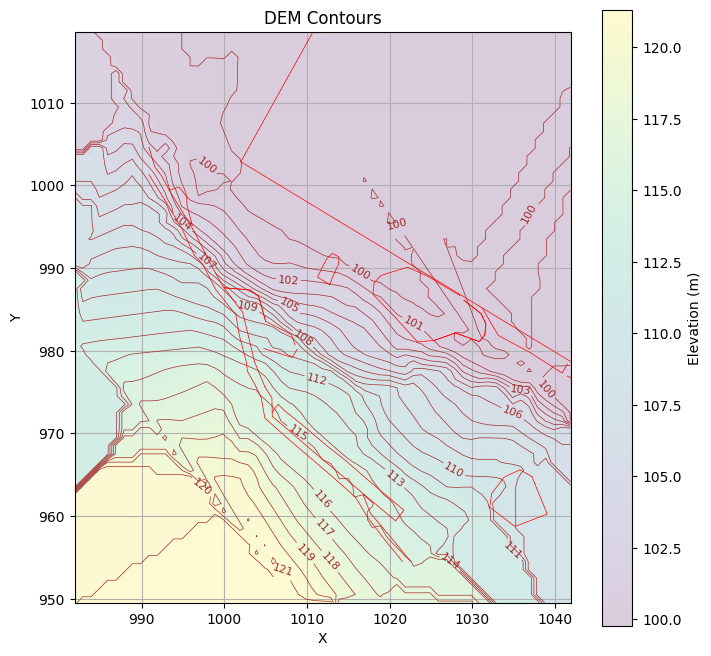

In [7]:
# @title
# ============================================
# 5. PLOT DEM
# ============================================
import ezdxf

dxf_file="Ranawana_Clean_Poly.dxf"

def plot_dxf_on_contour_fit(
    dxf_file, Xi, Yi, Zi,
    show_labels=False,
    x_offset=8,
    y_offset=2.5,
    line_color="blue",
    linewidth=0.5
):

  doc = ezdxf.readfile(dxf_file)
  msp = doc.modelspace()

  entities = []
  all_x, all_y = [], []

  for e in msp:
      if e.dxftype() == "LWPOLYLINE":
          pts = [(p[0], p[1]) for p in e.get_points()]
          entities.append((pts, e.closed))
          all_x += [p[0] for p in pts]
          all_y += [p[1] for p in pts]

  dxf_xmin, dxf_xmax = min(all_x), max(all_x)
  dxf_ymin, dxf_ymax = min(all_y), max(all_y)

  ctr_xmin, ctr_xmax = np.nanmin(Xi), np.nanmax(Xi)
  ctr_ymin, ctr_ymax = np.nanmin(Yi), np.nanmax(Yi)

  sx = (ctr_xmax - ctr_xmin) / (dxf_xmax - dxf_xmin)
  sy = (ctr_ymax - ctr_ymin) / (dxf_ymax - dxf_ymin)

  # -------------------------------------------------
  # Plot
  # -------------------------------------------------
  for pts, closed in entities:
      pts = np.array(pts)

      tx = (pts[:, 0] - dxf_xmin) * sx + ctr_xmin + x_offset
      ty = (pts[:, 1] - dxf_ymin) * sy + ctr_ymin + y_offset

      if closed:
          tx = np.append(tx, tx[0])
          ty = np.append(ty, ty[0])

      plt.plot(tx, ty, color=line_color, linewidth=linewidth)

  return entities

def plot_dem(Xi, Yi, Zi, levels=30, ims=None):

    cs = plt.contour(Xi, Yi, Zi, levels=levels, colors="brown", linewidths=0.5)
    plt.clabel(cs, inline=True, fontsize=8)

    plot_dxf_on_contour_fit(
      dxf_file, Xi, Yi, Zi,
      show_labels=False,
      x_offset=9, y_offset=5,
      line_color="red",
      linewidth=0.5
    )

    if ims is not None:
      plt.imshow(
          Zi,
          extent=(Xi.min(), Xi.max(), Yi.min(), Yi.max()),
          origin="lower",
          alpha=0.20
      )

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("DEM Contours")
    plt.grid(True)
    plt.colorbar(label="Elevation (m)")

levels=25
plt.figure(figsize=(8, 8))

plot_dem(Xi, Yi, Zi, levels, True)

plt.show()


Slope Map

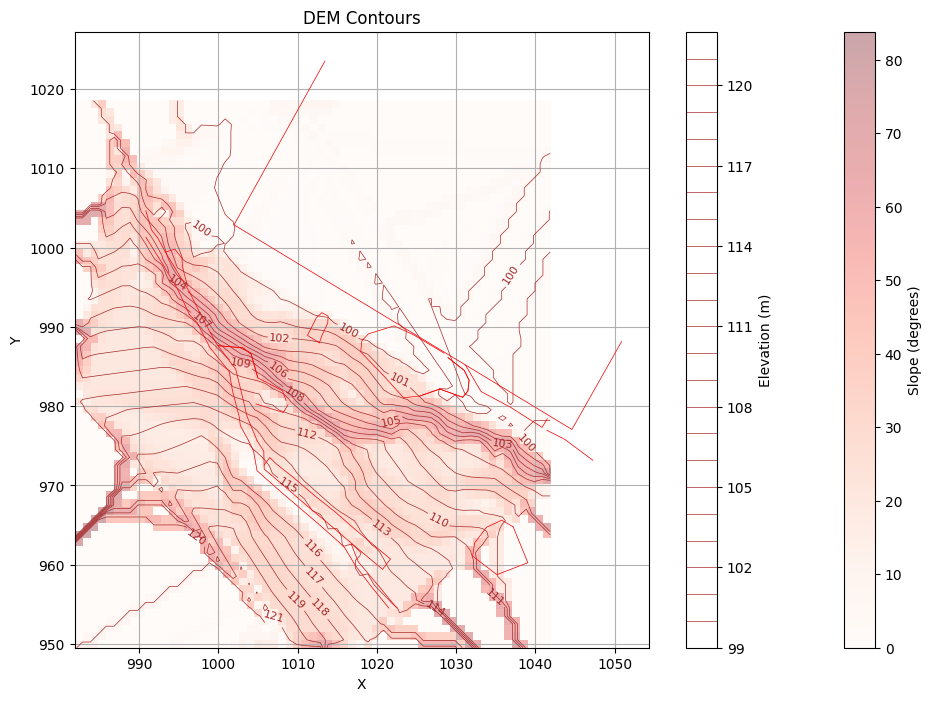

In [8]:
# @title
# ============================================
# 6. SLOPE MAP
# ============================================

def compute_slope_grid(Xi, Yi, Zi):
    dx = np.mean(np.diff(Xi[0, :]))
    dy = np.mean(np.diff(Yi[:, 0]))

    dz_dy, dz_dx = np.gradient(Zi, dy, dx)
    slope_deg = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))
    return slope_deg, dz_dx, dz_dy

def plot_slope_map(Xi, Yi, slope_deg, plt):


    plt.imshow(
    slope_deg,
    extent=(Xi.min(), Xi.max(), Yi.min(), Yi.max()),
    origin="lower",
    cmap="Reds",   # color style
    alpha=0.35         # opacity (0 = transparent, 1 = solid)
    )
    plot_dxf_on_contour_fit(
      dxf_file, Xi, Yi, Zi,
      show_labels=False,
      x_offset=9, y_offset=5,
      line_color="lightblue",
      linewidth=0.2
    )

    plt.colorbar(label="Slope (degrees)")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Slope Map")
    plt.grid(True)

plt.figure(figsize=(12, 8))
slope_deg, dz_dx, dz_dy = compute_slope_grid(Xi, Yi, Zi)
plot_slope_map(Xi, Yi, slope_deg, plt)
plot_dem(Xi, Yi, Zi, levels, None)
plt.savefig("Ranawana_slopemap.pdf", dpi=300,bbox_inches='tight', facecolor='white')
plt.show()

###Flow direction vectors

Water moves downhill, so use negative gradient.

# Stremlines

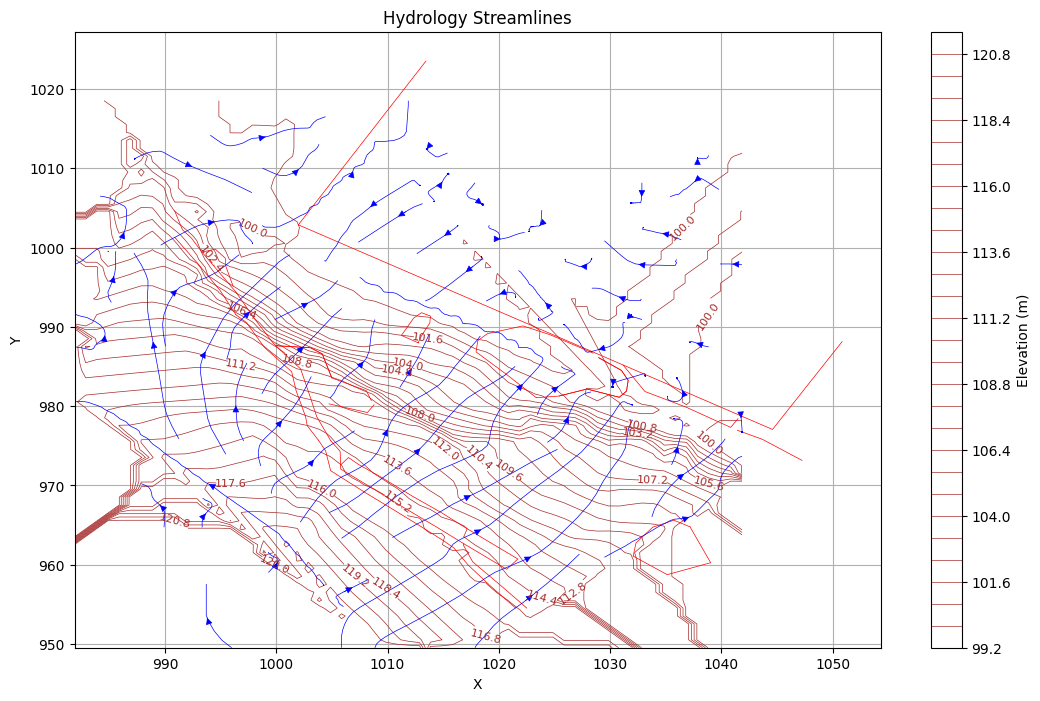

In [12]:
# @title
# ============================================
# 8. STREAMLINES
# ============================================

def plot_streamlines(Xi, Yi, Zi, levels=20, density=1.3):

    dx = np.mean(np.diff(Xi[0, :]))
    dy = np.mean(np.diff(Yi[:, 0]))

    dz_dy, dz_dx = np.gradient(Zi, dy, dx)

    # Water flows downhill
    U = -dz_dx
    V = -dz_dy
    flow_strength = np.sqrt(U**2 + V**2)

    #flow_mask = flow_strength > threshold
    # Plot stremlines
    plt.figure(figsize=(13, 8))
    plot_dem(Xi, Yi, Zi, levels, None)
    #plt.contour(Xi, Yi, Zi, levels=levels, colors="brown", linewidths=0.5)

    plt.streamplot(
    Xi[0, :],
    Yi[:, 0],
    -dz_dx,
    -dz_dy,
    density=.7,
    linewidth=0.5,
    color="blue" #flow_strength
    )


    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Hydrology Streamlines")
    plt.grid(True)


plot_streamlines(Xi, Yi, Zi, levels=30, density=1)
plt.savefig("Ranawana_streamlines.pdf", dpi=300,bbox_inches='tight', facecolor='white')
plt.show()

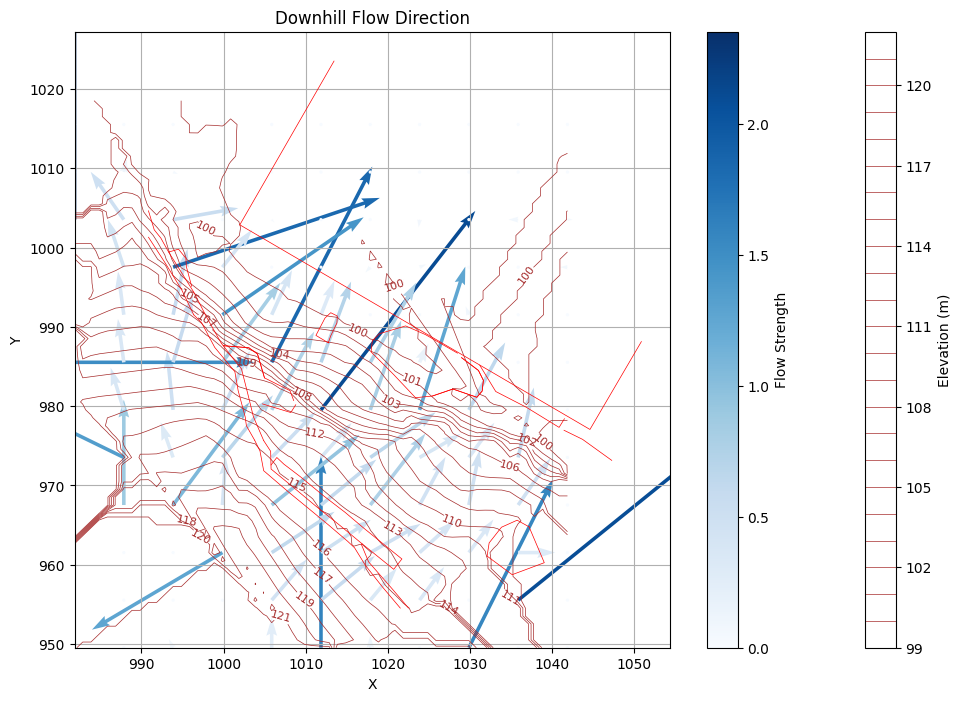

In [13]:
# @title
# ============================================
# 7. FLOW DIRECTION VECTORS
# ============================================

def plot_flow_vectors(Xi, Yi, Zi, step=5, levels=20):
    dx = np.mean(np.diff(Xi[0, :]))
    dy = np.mean(np.diff(Yi[:, 0]))

    dz_dy, dz_dx = np.gradient(Zi, dy, dx)
    mag = np.sqrt(dz_dx**2 + dz_dy**2)

    plt.figure(figsize=(12, 8))

    # DEM background
    plot_dem(Xi, Yi, Zi, levels)

    # Flow arrows
    q = plt.quiver(
        Xi[::step, ::step],
        Yi[::step, ::step],
        -dz_dx[::step, ::step],
        -dz_dy[::step, ::step],
        mag[::step, ::step],
        cmap="Blues",
        scale=5,
        width=0.006,
        alpha=1
    )

    plt.colorbar(q, label="Flow Strength")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Downhill Flow Direction")
    plt.grid(True)
    plt.show()

plot_flow_vectors(Xi, Yi, Zi, step=6, levels=25)



Streamlines are very useful because they show:

flow paths
convergence zones
drainage network

### Flow accumulation

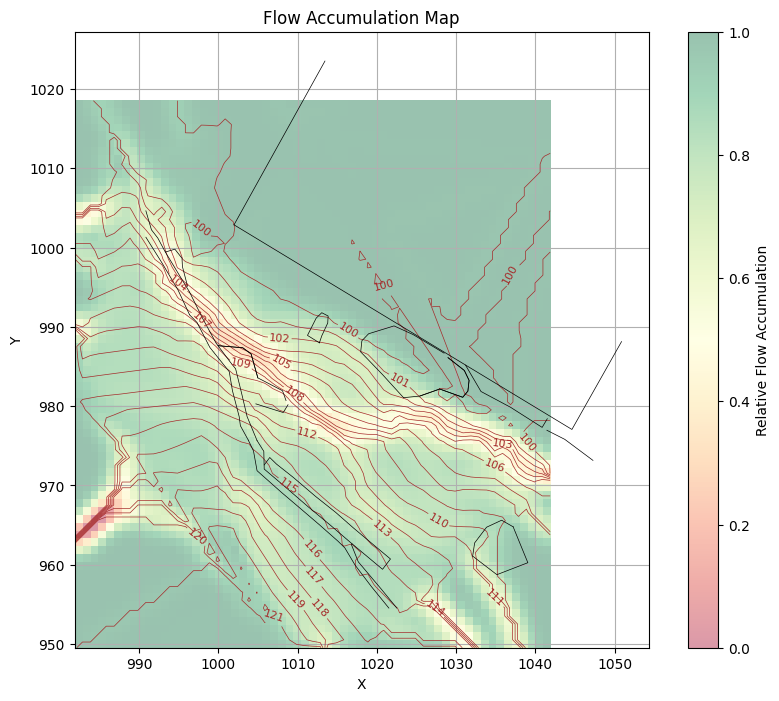

In [16]:
# @title
# ============================================
# 9. SIMPLE FLOW ACCUMULATION
# ============================================

def compute_flow_accumulation_simple(Zi, smooth_sigma=1.0):
    Zs = gaussian_filter(Zi, sigma=smooth_sigma)

    dzdx = sobel(Zs, axis=1)
    dzdy = sobel(Zs, axis=0)

    slope_mag = np.sqrt(dzdx**2 + dzdy**2)

    # inverse slope tendency as proxy for water collection
    flow_acc = np.maximum(np.nanmax(slope_mag) - slope_mag, 0)

    fmin, fmax = np.nanmin(flow_acc), np.nanmax(flow_acc)
    if fmax > fmin:
        flow_acc = (flow_acc - fmin) / (fmax - fmin)

    return flow_acc

def plot_flow_accumulation(Xi, Yi, flow_acc):

    plt.imshow(
        flow_acc,
        extent=(Xi.min(), Xi.max(), Yi.min(), Yi.max()),
        origin="lower",
        alpha=0.40,
        cmap="RdYlGn" #"RdYlGn"
    )


    plt.colorbar(label="Relative Flow Accumulation")


flow_acc = compute_flow_accumulation_simple(Zi, smooth_sigma=1.2)

plt.figure(figsize=(10, 8))
plot_flow_accumulation(Xi, Yi, flow_acc)
#plot_dem(Xi, Yi, Zi, levels) #, None)

cs = plt.contour(Xi, Yi, Zi, levels=levels, colors="brown", linewidths=0.5)
plt.clabel(cs, inline=True, fontsize=8)

plot_dxf_on_contour_fit(
      dxf_file, Xi, Yi, Zi,
      show_labels=False,
      x_offset=9, y_offset=5,
      line_color="black",
      linewidth=0.5
    )


plt.xlabel("X")
plt.ylabel("Y")
plt.title("Flow Accumulation Map")
plt.grid(True)
plt.savefig("Ranawana_Flow Accumulation.pdf", dpi=300,bbox_inches='tight', facecolor='white')
plt.show()

In [19]:
# @title
def plot_drainage_network(Xi, Yi, Zi, flow_acc, levels=20, percentile=90):

    # adaptive threshold
    thr = np.percentile(flow_acc, percentile)
    drainage = flow_acc > thr

    plt.figure(figsize=(8, 8))

    # contours
    plt.contour(Xi, Yi, Zi, levels=levels, colors="lightgray", linewidths=0.5)

    # drainage overlay
    plt.imshow(
        drainage.astype(float),
        extent=(Xi.min(), Xi.max(), Yi.min(), Yi.max()),
        origin="lower",
        alpha=0.5,
        cmap="Blues"
    )

    plt.title(f"Drainage Network (Top {percentile}%)")
    plt.axis("equal")
    plt.show()

Drainage extraction

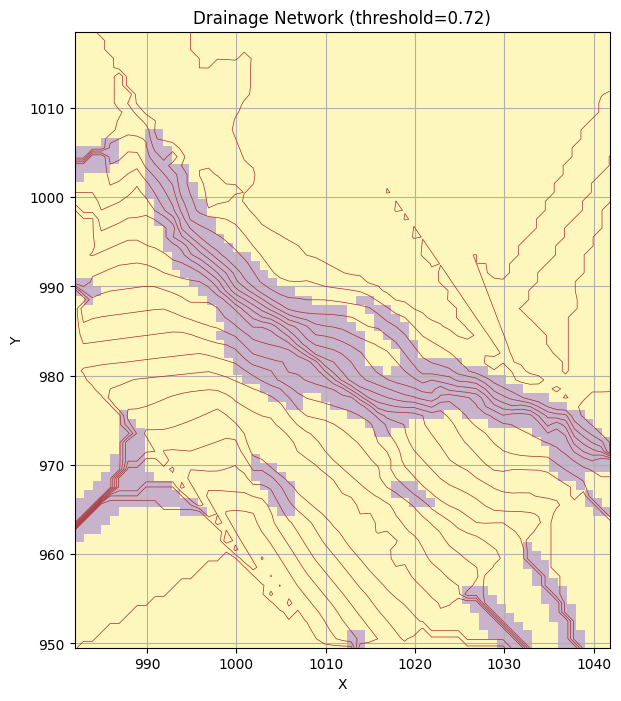

In [21]:
# @title
# ============================================
# 10. DRAINAGE EXTRACTION
# ============================================

def plot_drainage_network(Xi, Yi, Zi, flow_acc, threshold=0.7, levels=25):
    drainage = flow_acc > threshold

    plt.imshow(
        drainage.astype(float),
        extent=(Xi.min(), Xi.max(), Yi.min(), Yi.max()),
        origin="lower",
        alpha=0.3
    )


plt.figure(figsize=(8, 8))
plt.contour(Xi, Yi, Zi, levels=levels, colors="brown", linewidths=0.5)
threshold=0.72
plot_drainage_network(Xi, Yi, Zi, flow_acc, threshold=threshold, levels=25)

plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"Drainage Network (threshold={threshold})")
plt.grid(True)
plt.show()

Wetness index style map

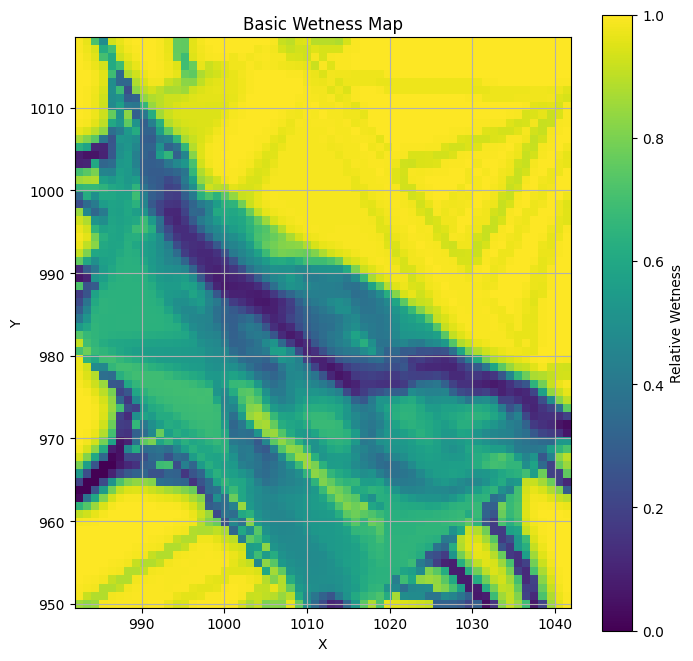

In [22]:
# @title
# ============================================
# 11. BASIC WETNESS MAP
# ============================================

def compute_basic_wetness(flow_acc, slope_deg):
    slope_norm = slope_deg / np.nanmax(slope_deg)
    wetness = flow_acc * (1 - slope_norm)

    wmin, wmax = np.nanmin(wetness), np.nanmax(wetness)
    if wmax > wmin:
        wetness = (wetness - wmin) / (wmax - wmin)

    return wetness

def plot_wetness_map(Xi, Yi, wetness):
    plt.figure(figsize=(8, 8))
    plt.imshow(
        wetness,
        extent=(Xi.min(), Xi.max(), Yi.min(), Yi.max()),
        origin="lower"
    )
    plt.colorbar(label="Relative Wetness")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Basic Wetness Map")
    plt.grid(True)
    plt.show()

wetness = compute_basic_wetness(flow_acc, slope_deg)
plot_wetness_map(Xi, Yi, wetness)

Combined hydrology map

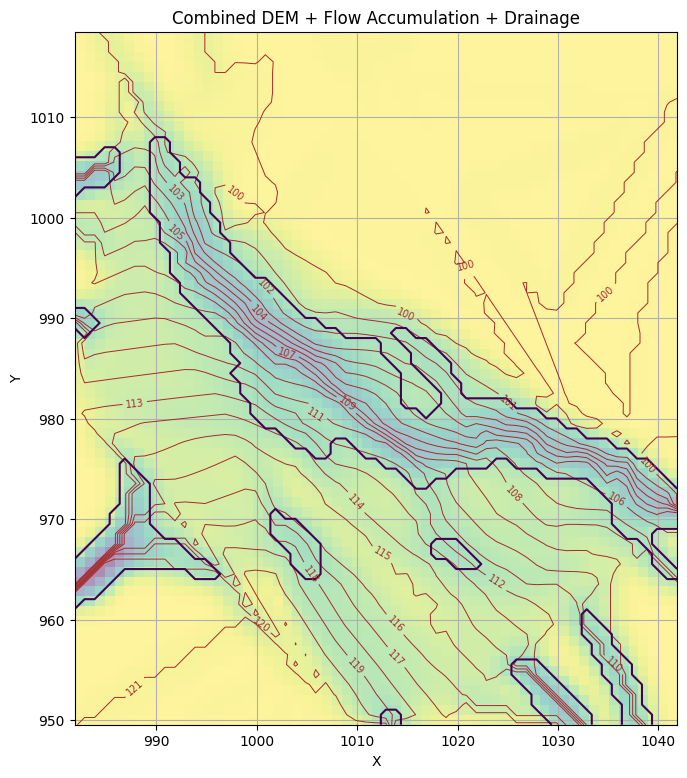

In [23]:
# @title
# ============================================
# 12. COMBINED HYDROLOGY MAP
# ============================================

def plot_combined_hydrology(Xi, Yi, Zi, flow_acc, threshold=0.72, levels=25):
    drainage = flow_acc > threshold

    plt.figure(figsize=(9, 9))

    cs = plt.contour(Xi, Yi, Zi, levels=levels, colors="brown", linewidths=0.7)
    plt.clabel(cs, inline=True, fontsize=7)

    plt.imshow(
        flow_acc,
        extent=(Xi.min(), Xi.max(), Yi.min(), Yi.max()),
        origin="lower",
        alpha=0.45
    )

    plt.contour(
        Xi, Yi, drainage.astype(float),
        levels=[0.5],
        linewidths=1.5
    )

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Combined DEM + Flow Accumulation + Drainage")
    plt.grid(True)
    #plt.colorbar(label="Relative Flow Accumulation")
    plt.show()

plot_combined_hydrology(Xi, Yi, Zi, flow_acc, threshold=0.72, levels=25)

In [25]:
# @title
# ============================================
# 13. SAVE OUTPUTS
# ============================================

output_dir = "/content"
os.makedirs(output_dir, exist_ok=True)

np.savez(
    os.path.join(output_dir, "hydrology_results.npz"),
    Xi=Xi,
    Yi=Yi,
    Zi=Zi,
    slope_deg=slope_deg,
    flow_acc=flow_acc,
    wetness=wetness
)

pd.DataFrame({
    "x": Xi.ravel(),
    "y": Yi.ravel(),
    "z": Zi.ravel(),
    "slope_deg": slope_deg.ravel(),
    "flow_acc": flow_acc.ravel(),
    "wetness": wetness.ravel()
}).to_csv(os.path.join(output_dir, "hydrology_results.csv"), index=False)

print("Saved to:", "hydrology_results.npz","hydrology_results.csv" )

Saved to: hydrology_results.npz hydrology_results.csv


### Main Cut-off Drain

- Reads DEM CSV
- interpolates it to a grid
- usesgiven start / end control
- forces the new crest cut-off drain to tie into the existing concrete drain
- keeps the path near the 110–111 m band
-exports the centreline to CSV

Algorithm

- Given a centreline with points every 1 m:

- Sample DEM elevation on the line.
- Compute chainage.
- Compute z_diff between consecutive points.
- Compute slope ratio for each 1 m segment.
- Define a target hydraulic fall per metre.
- Clean spikes and pits in the elevation profile.
- Build a smooth design line that:
- generally falls toward outlet
- does not create sudden rises
- respects a chosen minimum and maximum fall
- Reconstruct the final smoothed drain profile

Best Drain

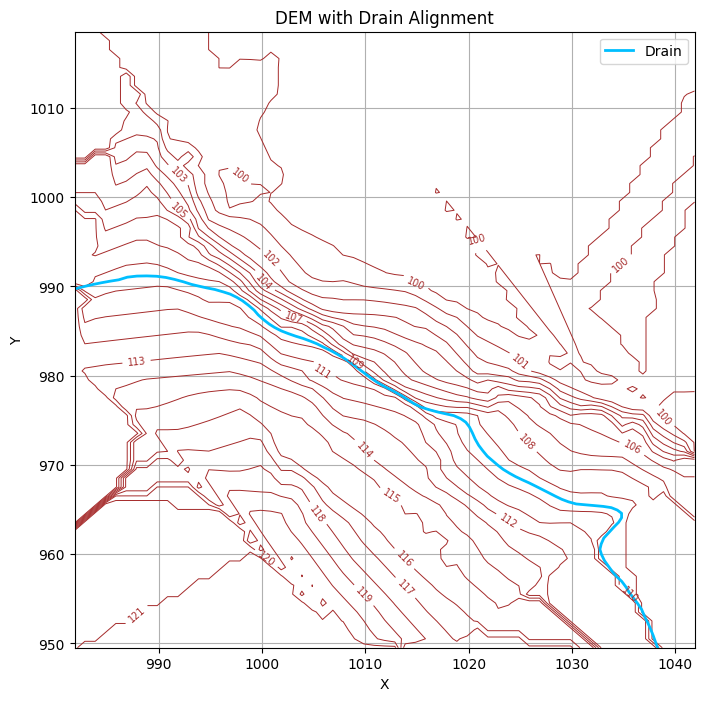

Done
Start ground level: 110.45052898314103
End invert level: 109.26704064731854


In [26]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.interpolate import RegularGridInterpolator

def extract_best_drain_from_contour(Xi, Yi, Zi, target_level=109.5):
    cs = plt.contour(Xi, Yi, Zi, levels=[target_level])

    best_line = None
    max_len = 0

    for seglist in cs.allsegs:
        for seg in seglist:
            if len(seg) > max_len:
                best_line = seg
                max_len = len(seg)

    plt.close()

    if best_line is None:
        raise ValueError("No contour found. Try 109, 108.5, or 110.")

    return np.asarray(best_line, dtype=float)

def smooth_polyline(xy, window=11, polyorder=2):
    xy = np.asarray(xy, dtype=float)

    if len(xy) < 5:
        return xy.copy()

    if window >= len(xy):
        window = len(xy) - 1 if len(xy) % 2 == 0 else len(xy)

    if window % 2 == 0:
        window -= 1

    if window < 3:
        return xy.copy()

    x = savgol_filter(xy[:, 0], window, polyorder)
    y = savgol_filter(xy[:, 1], window, polyorder)
    return np.column_stack((x, y))

def clip_polyline_to_grid(xy, Xi, Yi, margin=0.01):
    x_min, x_max = Xi.min(), Xi.max()
    y_min, y_max = Yi.min(), Yi.max()

    xy = np.asarray(xy, dtype=float).copy()
    xy[:, 0] = np.clip(xy[:, 0], x_min + margin, x_max - margin)
    xy[:, 1] = np.clip(xy[:, 1], y_min + margin, y_max - margin)
    return xy

def enforce_gradient(xy, Zi_func, slope=0.015):
    chainage = [0.0]
    for i in range(1, len(xy)):
        d = np.linalg.norm(xy[i] - xy[i - 1])
        chainage.append(chainage[-1] + d)

    chainage = np.array(chainage)

    base_z = np.array([Zi_func((p[1], p[0])) for p in xy], dtype=float)

    if np.isnan(base_z).any():
        raise ValueError("Some drain points are still outside DEM bounds.")

    invert_z = base_z[0] - slope * chainage
    return chainage, base_z, invert_z

def plot_dem_with_polyline(Xi, Yi, Zi, polyline_xy):
    fig, ax = plt.subplots(figsize=(8, 8))
    cs = ax.contour(Xi, Yi, Zi, levels=25, colors='brown', linewidths=0.7)
    ax.clabel(cs, inline=True, fontsize=7)

    xy = np.asarray(polyline_xy)
    ax.plot(xy[:, 0], xy[:, 1], color='deepskyblue', linewidth=2, label='Drain')
    ax.legend()
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title("DEM with Drain Alignment")
    ax.grid(True)
    plt.show()

# ---- run ----
drain_xy = extract_best_drain_from_contour(Xi, Yi, Zi, target_level=109.5)
drain_xy_smooth = smooth_polyline(drain_xy, window=11)
drain_xy_smooth = clip_polyline_to_grid(drain_xy_smooth, Xi, Yi)

Zi_func = RegularGridInterpolator(
    (Yi[:, 0], Xi[0, :]),
    Zi,
    bounds_error=False,
    fill_value=np.nan
)

chainage, ground_z, invert_z = enforce_gradient(drain_xy_smooth, Zi_func, slope=0.015)

plot_dem_with_polyline(Xi, Yi, Zi, drain_xy_smooth)

print("Done")
print("Start ground level:", ground_z[0])
print("End invert level:", invert_z[-1])